#### Name: Mason Miller

# PHYS 230 Lab Assignment 17

### Wednesday, April 8, 2026: Chapter 10.1
- Random numbers

In [44]:
# import statements here
import numpy as np
import random
import matplotlib.pyplot as plt


## Part 1: Testing random number generators

#### Step 1: Write a function `LCM_random(a,c,m,N,x)` that generates a list of $N$ random numbers using the linear congruent method from a starting seed $x$. 

In [34]:
# define the function
def LCM_random(a,c,m,N,x):
    # create a list to store the values
    vals = []

    # loop through to create random list
    for i in range(N):
        x = (a*x+c) % m
        vals.append(x/m)

    # return the value list
    return vals


#### Step 2: Call on your function from step 1 using the most accepted values of the constants $a,c$, and $m$, and whatever you want to use as the seed. Create an array $r$ of 1000 points. Repeat testing at least three different seeds total. 

In [35]:
# define three variable and apply the fuction, varying the seed
# define the ideal constants first
a = 1664525
c = 1013904223
m = 4294967296

r1 = LCM_random(a, c, m, 1000, 20)
r2 = LCM_random(a, c, m, 1000, 84)
r3 = LCM_random(a, c, m, 1000, 55)




#### Step 3: Make a plot (or separate plots may be best) of your arrays using Matplotlib Pyplot (simply feed in a single 1D array) to see how random the data truly is. In a markdown cell, explain any differences you notice when you use different seed values. 

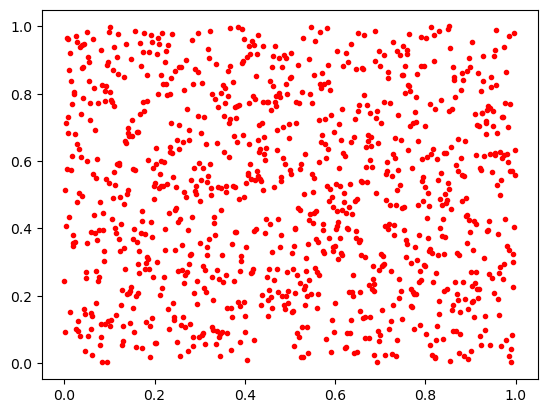

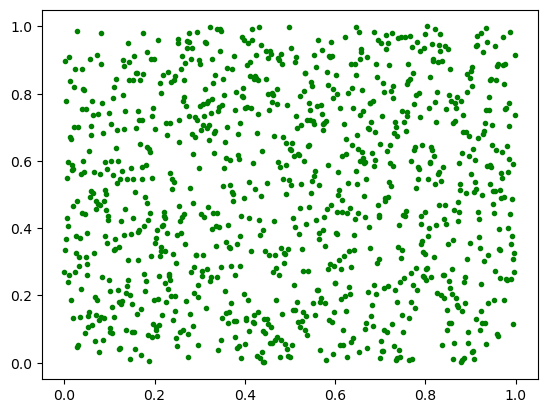

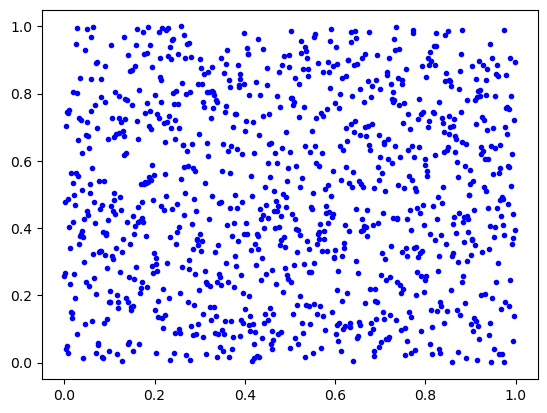

In [36]:
# make an array to plot over
x_arr = np.arange(0, 1, 0.001)

plt.plot(x_arr, r1, "r.")
plt.show()

plt.plot(x_arr, r2, "g.")
plt.show()

plt.plot(x_arr, r3, "b.")

There are variations tn the location of the dots, but generally the dots are uniformly spread out and 'random'

### <font color='purple'> Comments </font> 

<font color='purple'> nice job, could title with seed for clarificaiton</font> 


#### Step 4: Make a plot of successive random numbers for one of your arrays, where your plot points should be ($x,y$) = ($r_i$, $r_{i+1}$). What do you notice about this plot? Do the values truly seem random? 

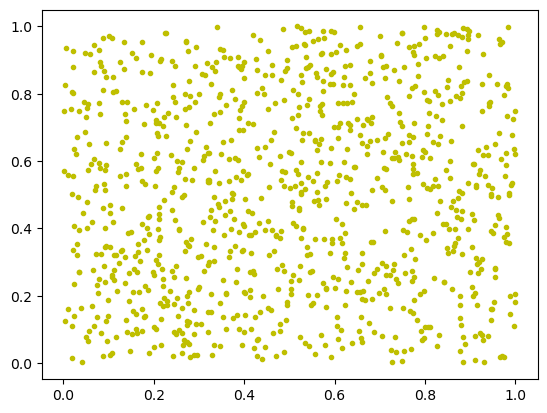

In [37]:
# ill use my array r1
r1 = LCM_random(a, c, m, 1000, 20)

# create x and y lists
x_vals = []
y_vals = []

# write a loop that will assign x = r_i and y = r_i+1
for i in range(len(r1) - 1):
    x_vals.append(r1[i])
    y_vals.append(r1[i+1])

plt.plot(x_vals, y_vals, 'y.')

This plot seems just as randon and homogenous as the previous three plots

#### Step 5: Now try an unwise choice of constant for the linear congruent method. Try using $(a,c,m,x) = (57,1,256,10)$ to generate 1000 random values. Make a 1D plot and also the plot (x,y) = ($r_i$, $r_{i+1}$). Explain what you notice about these plots compared to above. 

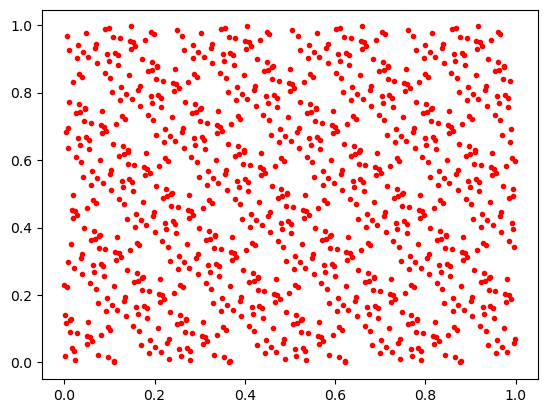

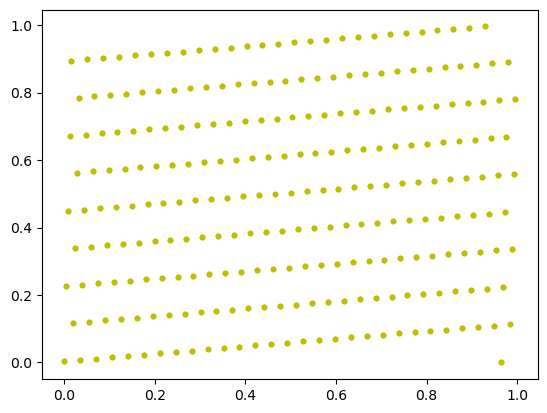

In [38]:
unwise = LCM_random(57, 1, 256, 1000, 10)

# make an array to plot over for 1d plot
x_arr = np.arange(0, 1, 0.001)

# plot 1d plot
plt.plot(x_arr, unwise, 'r.')
plt.show()

# create x and y lists for 2d plot
x_vals = []
y_vals = []

# write a loop that will assign x = r_i and y = r_i+1
for i in range(len(unwise) - 1):
    x_vals.append(unwise[i])
    y_vals.append(unwise[i+1])

plt.plot(x_vals, y_vals, 'y.')

Boy these dont seem random at all! They extend across the whole range and domain of the plot, but are structured and organized.

#### Step 6: Use a built-in random number generator from the `random` package to create an array of 1000 points. Plot the results and compare as done in steps 3 and 4 above. (Don't forget to include a markdown with your comparison.) 

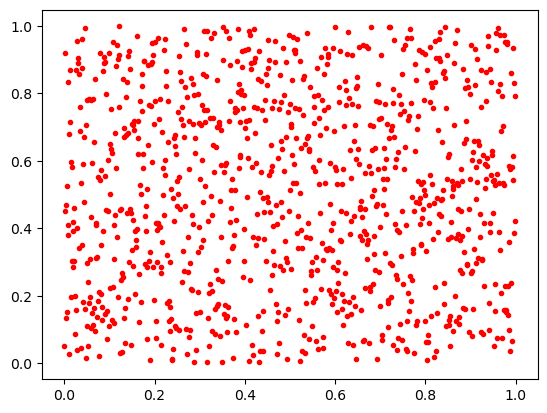

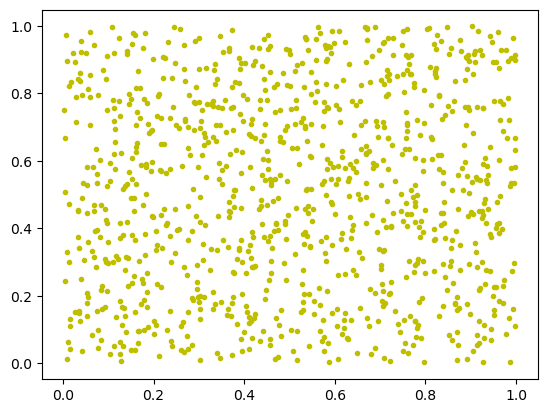

In [48]:
# use random to create a random list of points
N = 1000
rand_list = []

# loop to create the array of random numbers
for i in range(N):
    rand_list.append(random.random())

# make an array to plot over for 1d plot
x_arr = np.arange(0, 1, 0.001)

# plot 1d plot
plt.plot(x_arr, rand_list, 'r.')
plt.show()

# create x and y lists for 2d plot
x_vals = []
y_vals = []

# write a loop that will assign x = r_i and y = r_i+1
for i in range(len(rand_list) - 1):
    x_vals.append(rand_list[i])
    y_vals.append(rand_list[i+1])

plt.plot(x_vals, y_vals, 'y.')

Using the random package appears to properly create random numbers, as seen in the 1d and 2d plots

### <font color='purple'> Comments </font> 

<font color='purple'> great job! </font> 


## Part 2: Luck & Roulette 
(background information taken from [Wikipedia](https://en.wikipedia.org/wiki/Roulette))

Roulette is a casino game named after the French word meaning little wheel. In the game, a player may choose to place a bet on a single number, various groupings of numbers, the color red or black, whether the number is odd or even, or if the numbers are high (19–36) or low (1–18).

To determine the winning number, a croupier spins a wheel in one direction, then spins a ball in the opposite direction around a tilted circular track running around the outer edge of the wheel. The ball eventually loses momentum, passes through an area of deflectors, and falls onto the wheel and into one of  thirty-eight colored and numbered pockets on the wheel.

As explained above, there are many betting options for Roulette, seen on the roulette table layout below. One of the most common bets is either red or black. 

In this part of the lab, we're going to use a random number generator to determine the odds of winning when a gambling soul chooses red. 


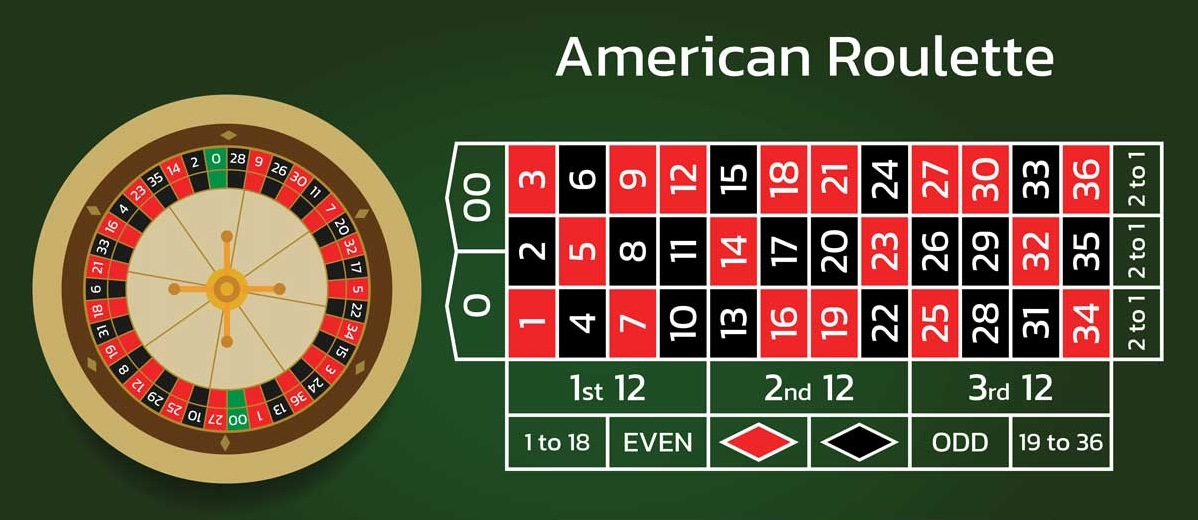

#### Step 1: Create two lists - `red` and `black` - which each contain all of the numbers that belong to those classifications. 

In [54]:
# create the lists
red = [1, 3, 5, 7, 9, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 32, 34, 36]
black = [2, 4, 6, 8, 10, 11, 13, 15, 17, 20, 22, 24, 26, 28, 29, 31, 33, 35]

#### Step 2: Develop a *function* to spin the roulette wheel $N$ times. 

In the code it should: 
- create three variables (red_count, black_count, green_count) initially set equal to 0 (Green count will be used to keep track of 0 & 00)
- select a random number between 1 and 38 (37 and 38 are being used to represent 0 and 00 for this game)
- check if that number is in red or black list (or neither) - this would be best done with if, elif, and else
- if the number is red, black, or neither, add one to the corresponding variable from step 2. 

In [55]:
def gambling(N):
    # define the initial counts  
    red_count = 0
    black_count = 0
    green_count = 0
    # N is to determine how many times the function loops
    # use random package to generate random numbers between 1 and 38
    
    for i in range(N):
        num = random.randint(1, 38)
        # boolean statements to determine if the wheel landed on red black or green, updating the count
        if num in red:
            red_count += 1
        elif num in black:
            black_count += 1
        else:
            green_count += 1

    return red_count, black_count, green_count

### <font color='purple'> Comments </font> 

<font color='purple'> your random needed to go to 39 since the last number is not included. Your percentage below are off becuase you did not include all the green values</font> 


#### Step 3: Call on your function to spin the roulette wheel 100, 1000, and 10,000 times. 

For each completion, determine what percentage of the spins were indeed red. 

In [75]:
# 100 times
hundred_times = gambling(100)
red_100 = hundred_times[0]
print('The ball landed on red', red_100, 'times out of 100, or', (red_100/100)*100, "%")

# 1000 times
thousand_times = gambling(1000)
red_1000 = thousand_times[0]
print('The ball landed on red', red_1000, 'times out of 1000, or', (red_1000/1000)*100, "%")

# 10000 times
tenthou_times = gambling(10000)
red_10000 = tenthou_times[0]
print('The ball landed on red', red_10000, 'times out of 10000, or', (red_10000/10000)*100, "%")

The ball landed on red 58 times out of 100, or 57.99999999999999 %
The ball landed on red 447 times out of 1000, or 44.7 %
The ball landed on red 4653 times out of 10000, or 46.53 %


#### Step 4: Vegas pays 1:1 for a red or black winning number, which would suggest you have a 50% chance of getting it right. Is this correct or is Vegas always putting the odds in their favor? Explain briefly. 

It appears that in the long run, the chance of getting red is around 47%. This makes sense, as the odds of getting a red bet right are 18/38, where the house wins on both black and the two green numbers. This is the edge that the house has: even if you bet on black, the odds are still 18/39.

### <font color='purple'> Comments </font> 

<font color='purple'> good</font> 
